<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul11_Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ======================================================
# 🔹 SETUP DAN IMPORT LIBRARY
# ======================================================
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


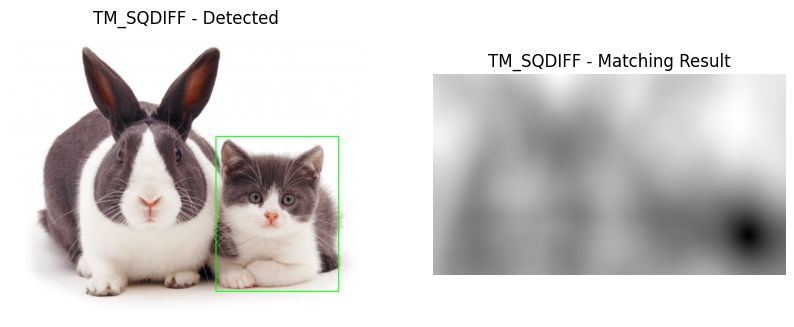

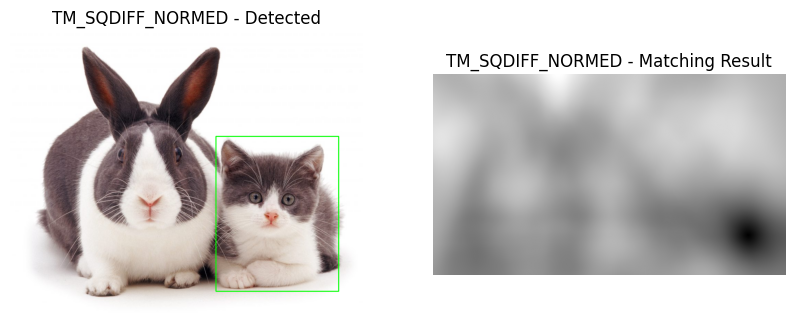

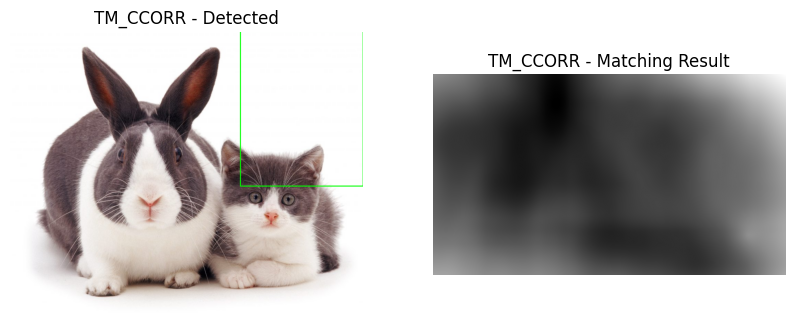

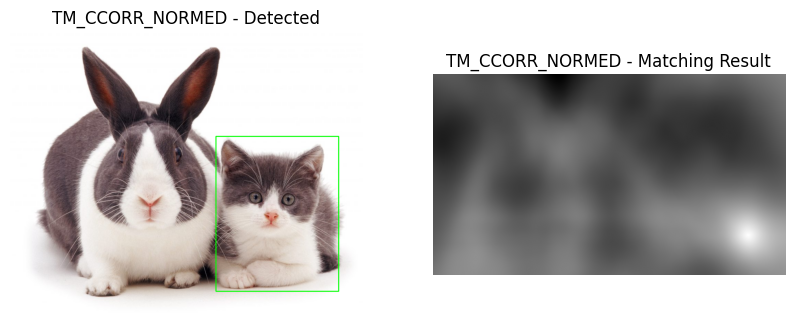

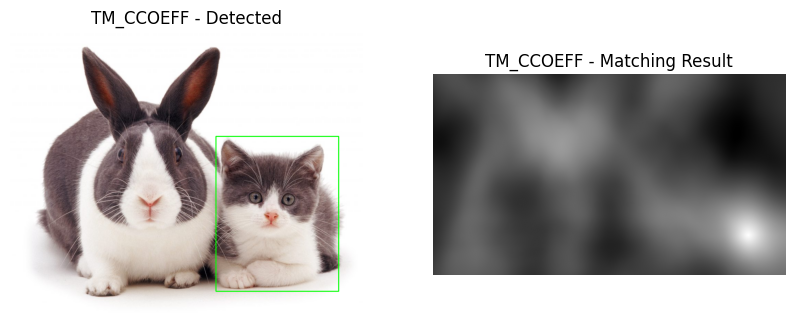

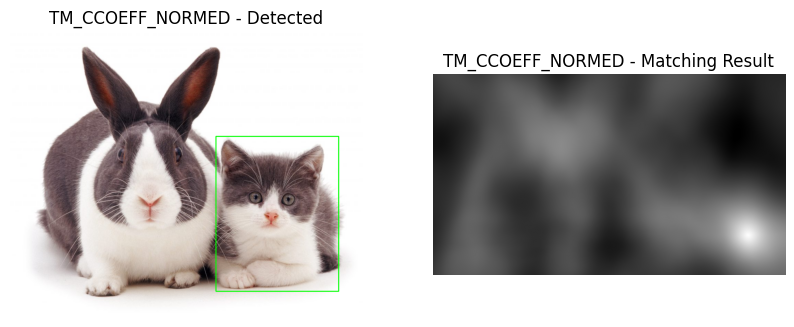

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/cats_and_bunnies.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/Images/cat2_template.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
h, w = template_gray.shape

methods = [
    ('TM_SQDIFF', cv.TM_SQDIFF),
    ('TM_SQDIFF_NORMED', cv.TM_SQDIFF_NORMED),
    ('TM_CCORR', cv.TM_CCORR),
    ('TM_CCORR_NORMED', cv.TM_CCORR_NORMED),
    ('TM_CCOEFF', cv.TM_CCOEFF),
    ('TM_CCOEFF_NORMED', cv.TM_CCOEFF_NORMED)
]

for name, method in methods:
    # Hitung template matching
    result = cv.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

    # Tentukan titik pencocokan terbaik
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)
    matched_img = img.copy()
    cv.rectangle(matched_img, top_left, bottom_right, (0,255,0), 2)

    # === Tampilan hasil ===
    plt.figure(figsize=(10,4))

    # 1️⃣ Hasil gambar dengan rectangle
    plt.subplot(1,2,1)
    plt.imshow(cv.cvtColor(matched_img, cv.COLOR_BGR2RGB))
    plt.title(f'{name} - Detected'); plt.axis('off')

    # 2️⃣ Hasil peta korelasi (matching result)
    plt.subplot(1,2,2)
    plt.imshow(result, cmap='gray')
    plt.title(f'{name} - Matching Result'); plt.axis('off')

    plt.show()

## Template Matching Manual (Tanpa OpenCV)

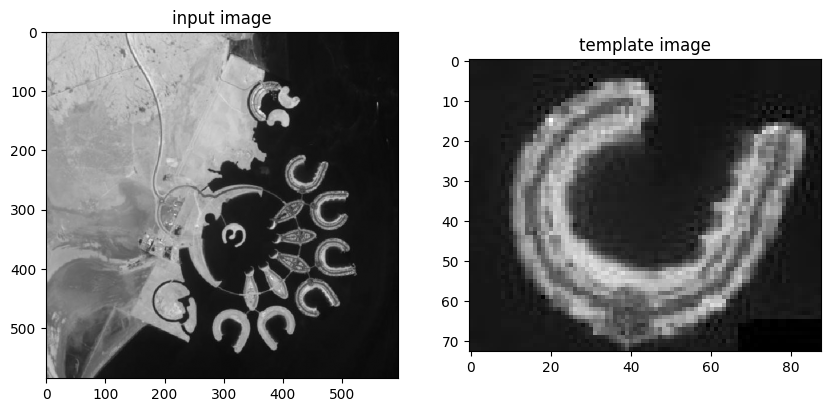

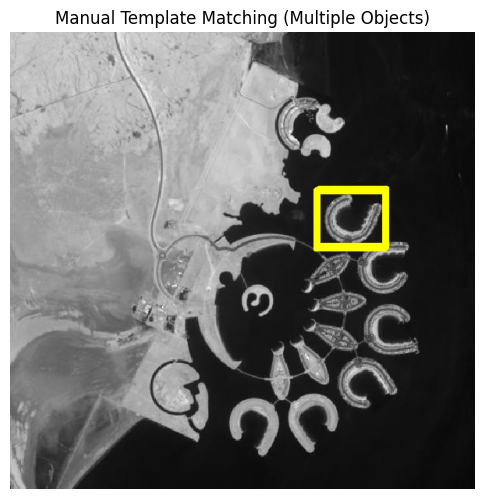

In [6]:
# --- Fungsi Normalized Cross-Correlation (manual) ---
def normalized_cross_correlation(source, template):
    s_h, s_w = source.shape
    t_h, t_w = template.shape
    tpl_mean, tpl_std = np.mean(template), np.std(template)
    result = np.zeros((s_h - t_h + 1, s_w - t_w + 1), dtype=np.float32)

    # Hitung korelasi normalisasi setiap patch
    for y in range(result.shape[0]):
        for x in range(result.shape[1]):
            patch = source[y:y+t_h, x:x+t_w]
            patch_mean, patch_std = np.mean(patch), np.std(patch)
            if patch_std != 0 and tpl_std != 0:
                result[y, x] = np.sum((patch - patch_mean) * (template - tpl_mean)) / (t_h * t_w * patch_std * tpl_std)
    return result

# --- Load citra ---
img = cv.imread('/content/drive/MyDrive/PCVK/Images/bahrain.jpg', cv.IMREAD_GRAYSCALE)
tpl = cv.imread('/content/drive/MyDrive/PCVK/Images/bahrain-template.jpg', cv.IMREAD_GRAYSCALE)

# --- Tampilkan gambar input & template ---
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('input image')
plt.subplot(1,2,2)
plt.imshow(tpl, cmap='gray')
plt.title('template image')
plt.show()

# --- Proses Template Matching manual ---
res = normalized_cross_correlation(img, tpl)

# --- Tentukan posisi threshold kecocokan ---
threshold = 0.6
y, x = np.where(res >= threshold)

# --- Visualisasi hasil ---
vis = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
for (xx, yy) in zip(x, y):
    cv.rectangle(vis, (xx, yy), (xx+tpl.shape[1], yy+tpl.shape[0]), (0,255,255), )  # kotak kuning

plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title('Manual Template Matching (Multiple Objects)')
plt.axis('off')
plt.show()

## Edge Detection (Sobel, Canny, Laplacian)

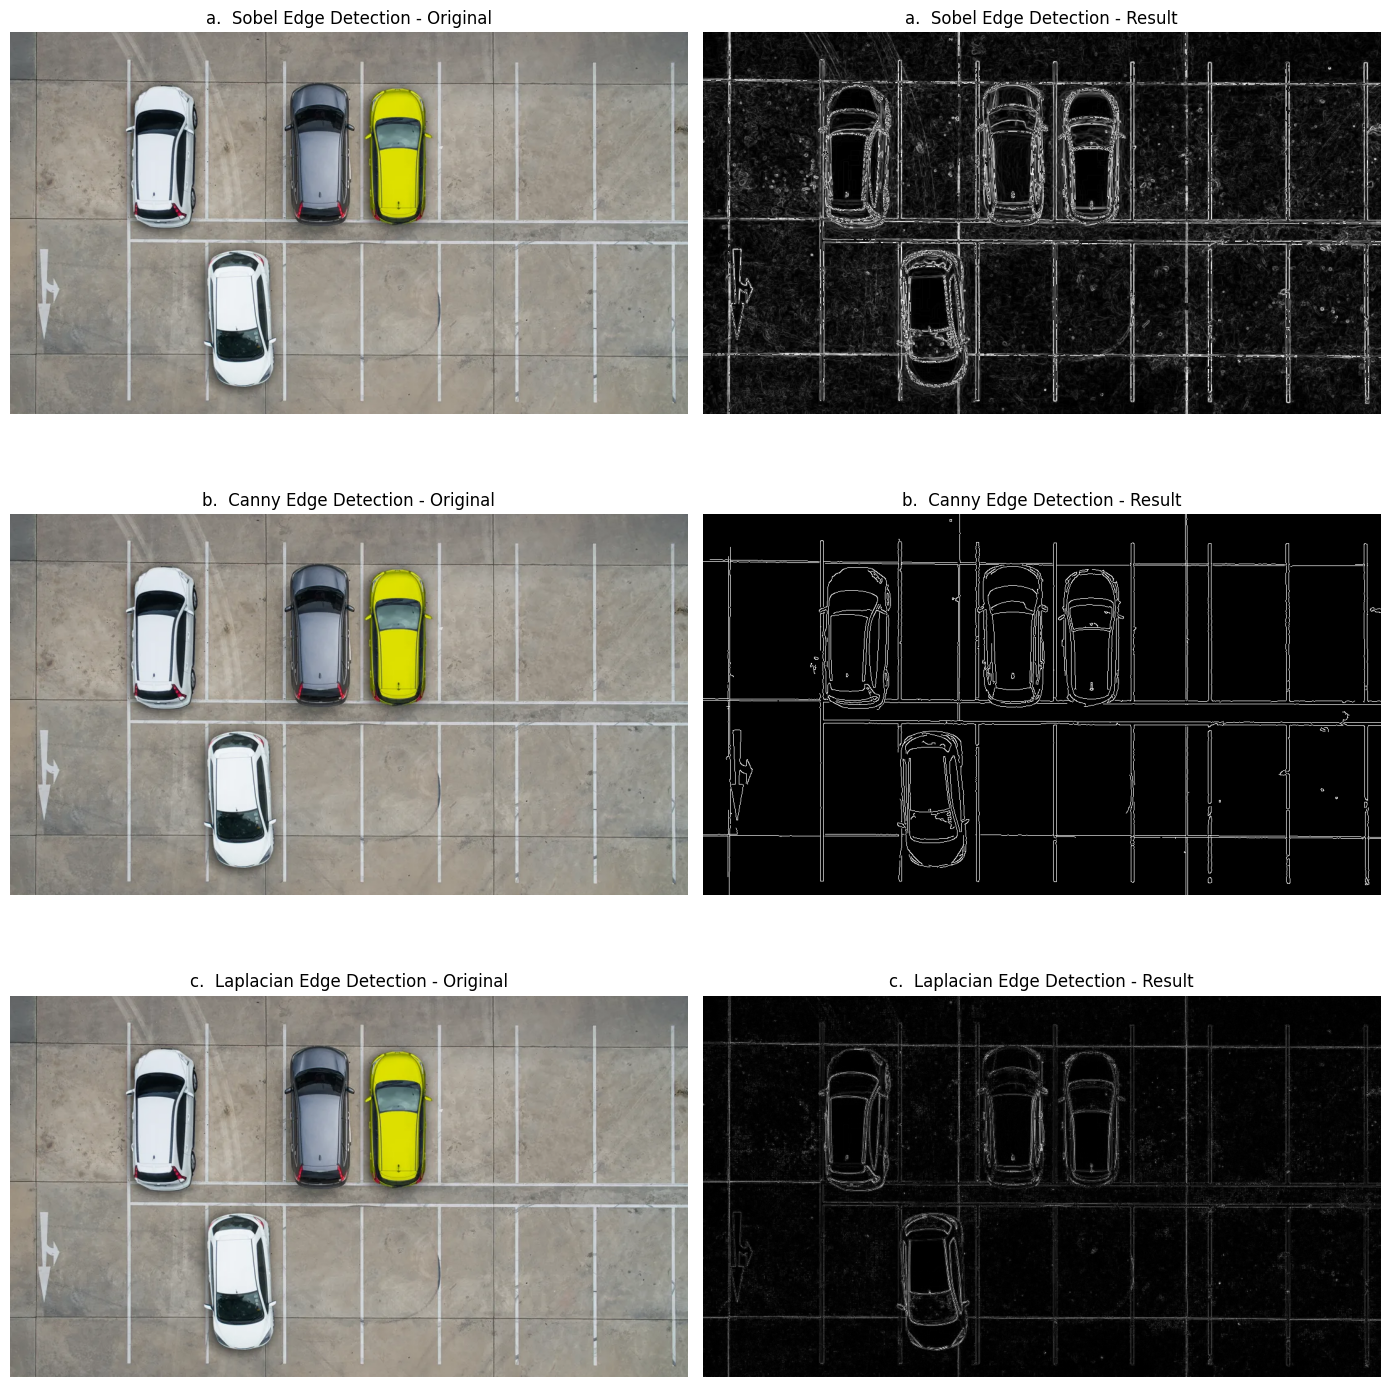

In [10]:
# ============ Load Gambar ============
img = cv.imread('/content/drive/MyDrive/PCVK/Images/car-park.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# ============ Sobel ============
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel = cv.magnitude(sobelx, sobely)
sobel = np.uint8(np.absolute(sobel))

# ============ Canny ============
blur = cv.GaussianBlur(gray, (5,5), 1)
canny = cv.Canny(blur, 50, 150)

# ============ Laplacian ============
lap = cv.Laplacian(gray, cv.CV_64F)
lap = np.uint8(np.absolute(lap))


# ============ Tampilkan seperti contoh ============

plt.figure(figsize=(14,15))

# ---- a. Sobel ----
plt.subplot(3,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("a.  Sobel Edge Detection - Original")
plt.axis('off')

plt.subplot(3,2,2)
plt.imshow(sobel, cmap='gray')
plt.title("a.  Sobel Edge Detection - Result")
plt.axis('off')


# ---- b. Canny ----
plt.subplot(3,2,3)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("b.  Canny Edge Detection - Original")
plt.axis('off')

plt.subplot(3,2,4)
plt.imshow(canny, cmap='gray')
plt.title("b.  Canny Edge Detection - Result")
plt.axis('off')


# ---- c. Laplacian ----
plt.subplot(3,2,5)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("c.  Laplacian Edge Detection - Original")
plt.axis('off')

plt.subplot(3,2,6)
plt.imshow(lap, cmap='gray')
plt.title("c.  Laplacian Edge Detection - Result")
plt.axis('off')

plt.tight_layout()
plt.show()

## Harris & Shi-Tomasi Corner Detection

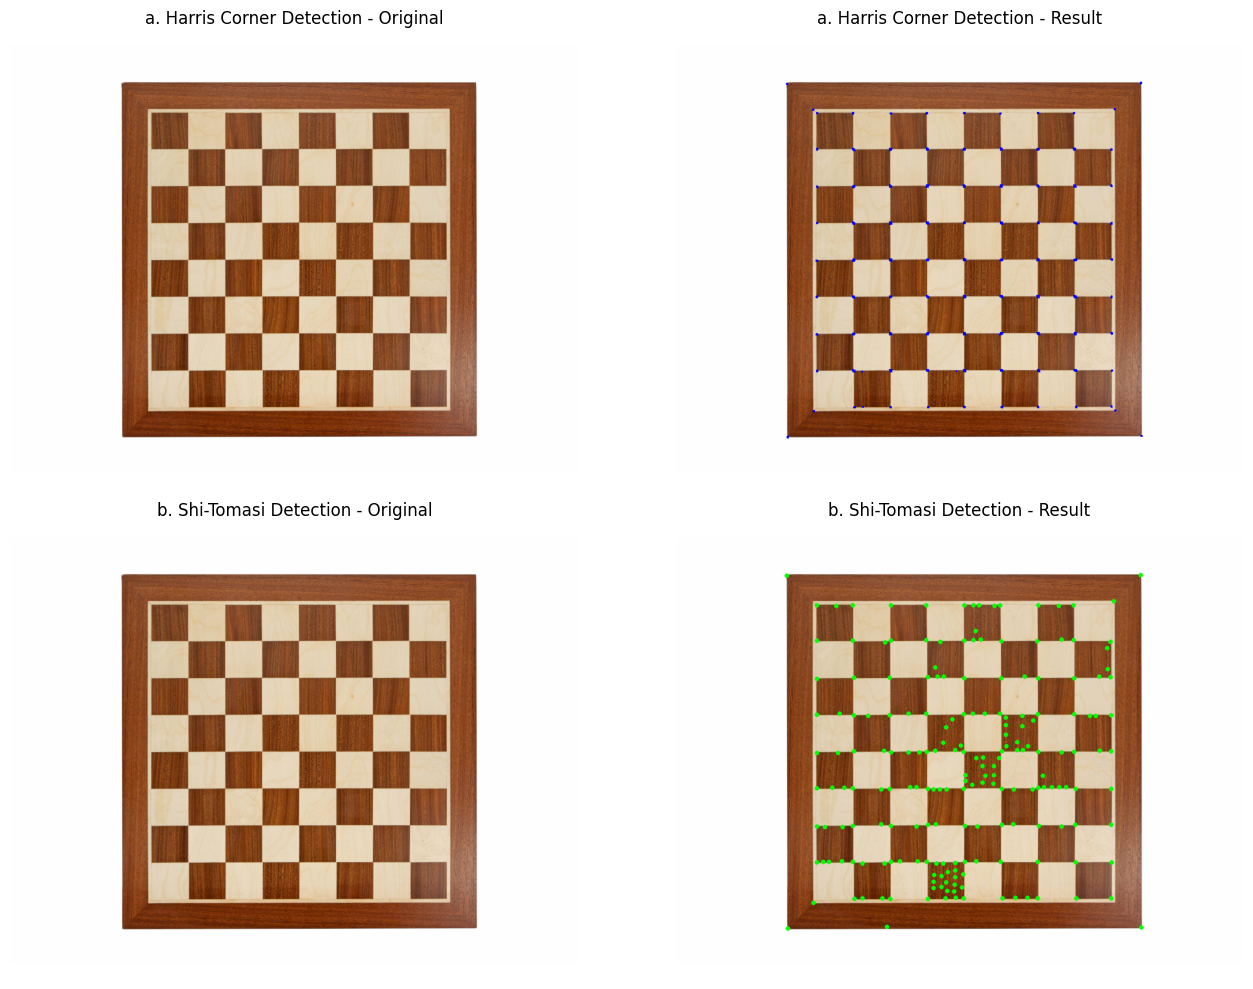

In [12]:
# ============================
# LOAD IMAGE
# ============================
img = cv.imread('/content/drive/MyDrive/PCVK/Images/chess-board.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_f = np.float32(gray)

# ===========================================================
# a. HARRIS CORNER DETECTION
# ===========================================================
dst = cv.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)
dst = cv.dilate(dst, None)  # memperkuat titik sudut

harris = img.copy()
harris[dst > 0.01 * dst.max()] = [255, 0, 0]   # tandai titik merah


# ===========================================================
# b. SHI–TOMASI CORNER DETECTION
# ===========================================================
shi = img.copy()
corners = cv.goodFeaturesToTrack(gray, maxCorners=200, qualityLevel=0.01, minDistance=10)

if corners is not None:
    for c in corners:
        x, y = c.ravel()
        cv.circle(shi, (int(x), int(y)), 4, (0,255,0), -1)   # titik hijau


# ===========================================================
# TAMPILKAN HASIL (format seperti modul)
# ===========================================================
plt.figure(figsize=(14,10))

# ---- a. Harris ----
plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("a. Harris Corner Detection - Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(cv.cvtColor(harris, cv.COLOR_BGR2RGB))
plt.title("a. Harris Corner Detection - Result")
plt.axis('off')

# ---- b. Shi–Tomasi ----
plt.subplot(2,2,3)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("b. Shi-Tomasi Detection - Original")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(cv.cvtColor(shi, cv.COLOR_BGR2RGB))
plt.title("b. Shi-Tomasi Detection - Result")
plt.axis('off')

plt.tight_layout()
plt.show()

## Hough Transform

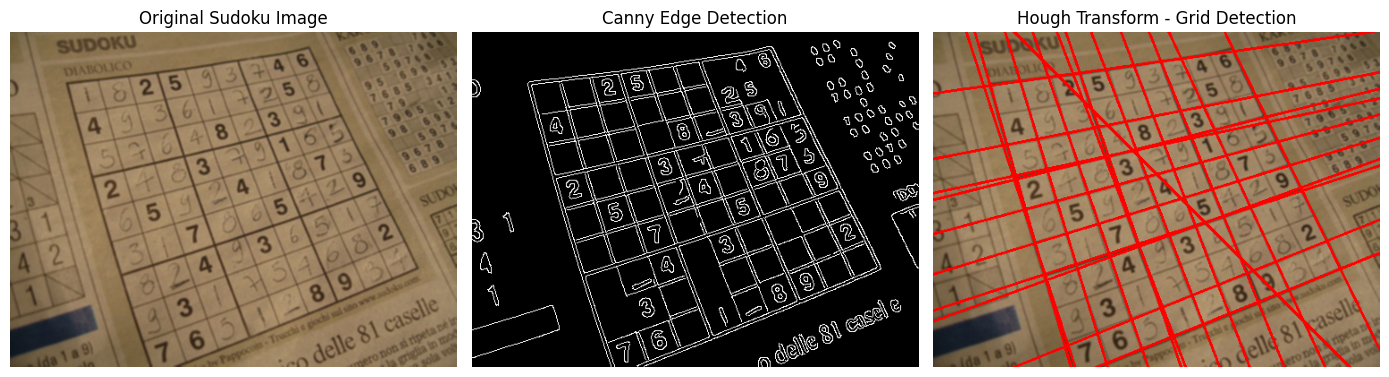

In [34]:
# ==========================
# LOAD IMAGE
# ==========================
img = cv.imread('/content/drive/MyDrive/PCVK/Images/sudoku.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# ==========================
# 1. PREPROCESSING
# ==========================
blur = cv.GaussianBlur(gray, (5,5), 0)
edges = cv.Canny(blur, 50, 150)

# --- DILATION ---
kernel = np.ones((5,5), np.uint8)
dilated = cv.dilate(edges, kernel, iterations=1)

# --- EROSION ---
eroded = cv.erode(dilated, kernel, iterations=1)

# ==========================
# 2. HOUGH TRANSFORM
# ==========================
lines = cv.HoughLines(eroded, 1, np.pi/180, 225)

hough_img = img.copy()

# ==========================
# 3. MERGE SIMILAR LINES
# ==========================
def is_similar(l1, l2, rho_thresh=15, theta_thresh=np.pi/90):
    return (abs(l1[0] - l2[0]) < rho_thresh) and (abs(l1[1] - l2[1]) < theta_thresh)

final_lines = []

for line in lines:
    rho, theta = line[0]
    if len(final_lines) == 0:
        final_lines.append((rho, theta))
    else:
        if not any(is_similar((rho, theta), fl) for fl in final_lines):
            final_lines.append((rho, theta))

# ==========================
# 4. DRAW LINES
# ==========================
for rho, theta in final_lines:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 2000*(-b))
    y1 = int(y0 + 2000*(a))
    x2 = int(x0 - 2000*(-b))
    y2 = int(y0 - 2000*(a))
    cv.line(hough_img, (x1, y1), (x2, y2), (0,0,255), 2)

# ==========================
# 5. SHOW RESULTS
# ==========================
plt.figure(figsize=(14,8))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Sudoku Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(hough_img, cv.COLOR_BGR2RGB))
plt.title("Hough Transform - Grid Detection")
plt.axis('off')

plt.tight_layout()
plt.show()

## Contour Detection – findContours()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


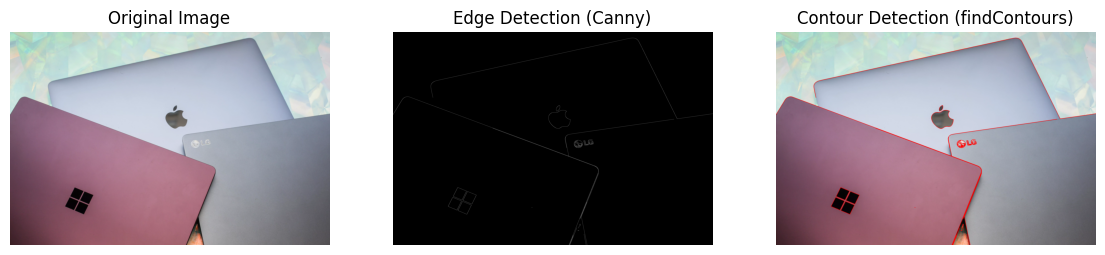

In [25]:
# =============================
# LOAD IMAGE
# =============================
img = cv.imread('/content/drive/MyDrive/PCVK/Images/laptop.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# =============================
# 1. PREPROCESSING
# =============================
# Smooth image
blur = cv.GaussianBlur(gray, (5,5), 0)

# Edge detection (lebih cocok untuk laptop)
edges = cv.Canny(blur, 60, 150)

# =============================
# 2. FIND CONTOURS
# =============================
contours, hierarchy = cv.findContours(
    edges,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

# Copy image
contour_img = img.copy()

# Gambar contour halus berwarna merah
cv.drawContours(contour_img, contours, -1, (0,0,255), 3)

# =============================
# 3. TAMPILKAN HASIL
# =============================
plt.figure(figsize=(14,8))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(contour_img, cv.COLOR_BGR2RGB))
plt.title("Contour Detection (findContours)")
plt.axis('off')

plt.show()